<a href="https://colab.research.google.com/github/Ysabellyysa/Python/blob/main/CNN_Pr%C3%A1tica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CNN_For_Cifar_Prática

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = y_train.flatten(), y_test.flatten()
print(x_train.shape, x_test.shape)

(50000, 32, 32, 3) (10000, 32, 32, 3)


In [5]:
K = len(set(y_train))  # 10 classes
print('classes:', K)

classes: 10


In [6]:

i = Input(shape=x_train[0].shape)

# filtros pequenos para pegar bordas
x = Conv2D(64,  (3, 3), strides=2, activation='relu', padding='same')(i)

# essa seção dobra os filtros
x = Conv2D(128, (3, 3), strides=2, activation='relu', padding='same')(x)

# mais profundidade
x = Conv2D(256, (3, 3), strides=2, activation='relu', padding='same')(x)

# GlobalAveragePooling em vez de Flatten menos parâmetros e mais robusto
x = GlobalAveragePooling2D()(x)

x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 16, 16, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 439,178 (1.68 MB)

 Trainable params: 439,178 (1.68 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

r = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=15)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 47ms/step - accuracy: 0.3265 - loss: 1.7851 - val_accuracy: 0.4303 - val_loss: 1.5431
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 45ms/step - accuracy: 0.4552 - loss: 1.4765 - val_accuracy: 0.5115 - val_loss: 1.3150
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 47ms/step - accuracy: 0.5078 - loss: 1.3377 - val_accuracy: 0.5576 - val_loss: 1.2107
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 45ms/step - accuracy: 0.5475 - loss: 1.2419 - val_accuracy: 0.5904 - val_loss: 1.1290
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 45ms/step - accuracy: 0.5775 - loss: 1.1681 - val_accuracy: 0.5959 - val_loss: 1.1139
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 45ms/step - accuracy: 0.6031 - loss: 1.1005 - val_accuracy: 0.6085 - val_loss: 1.0729
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 47ms/step - accuracy: 0.6282 - loss: 1.0369 - val_accuracy: 0.6273 - val_loss: 1.0310
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 46ms/step - accuracy: 0.6430 -

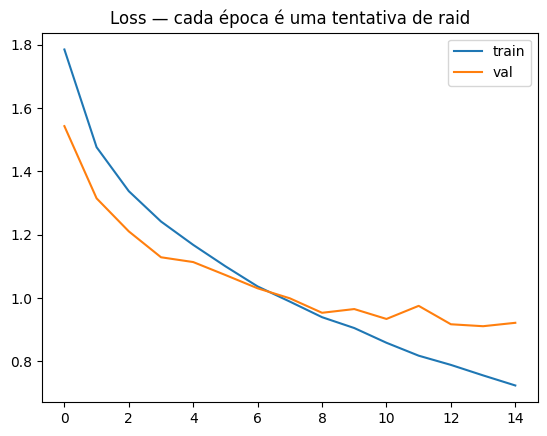

In [8]:
#resultado loss em gráfico
plt.plot(r.history['loss'], label='train')
plt.plot(r.history['val_loss'], label='val')
plt.title('Loss — cada época é uma tentativa de raid')
plt.legend()
plt.show()

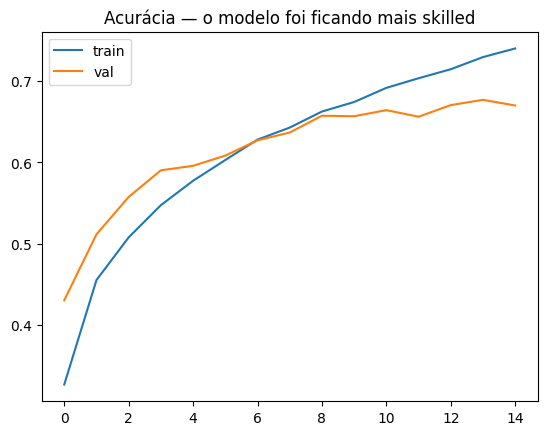

In [9]:

# resultado acurácia em gráfico
plt.plot(r.history['accuracy'], label='train')
plt.plot(r.history['val_accuracy'], label='val')
plt.title('Acurácia — o modelo foi ficando mais skilled')
plt.legend()
plt.show()

In [10]:
from sklearn.metrics import confusion_matrix # importa a função que calcula a matriz
import itertools# biblioteca auxiliar para criação de loops

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


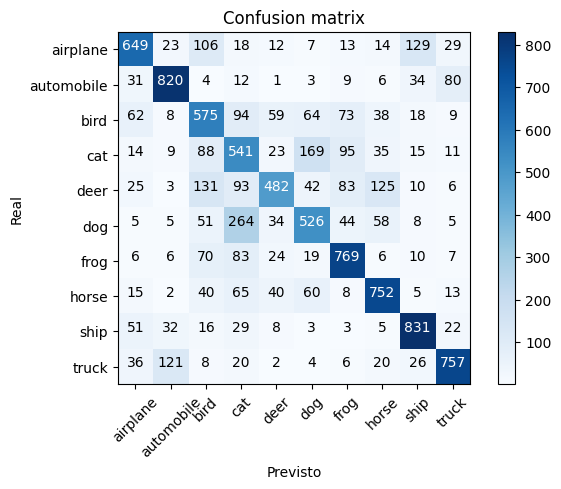

In [11]:
# define a função que vai desenhar o gráfico
def plot_confusion_matrix(cm, classes, normalize=False,
                          title='Confusion matrix', cmap=plt.cm.Blues):

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # desenha a matriz como uma imagem colorida
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title) # título
    plt.colorbar()   # adiciona a barra lateral que mostra a escala de cores

    # configura os nomes das categorias nos eixos X e Y
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45) # nomes embaixo inclinando em 45 graus
    plt.yticks(tick_marks, classes)               # nomes na lateral

    # define se o texto dentro dos quadrados
    fmt = '.2f' if normalize else 'd'

    # define um limite de cor para o texto
    thresh = cm.max() / 2.

    # loop que percorre a matriz para escrever o valor numérico nele
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')

    plt.tight_layout() # ajusta o layout para não cortar as legendas
    plt.ylabel('Real') # legenda do eixo vertical
    plt.xlabel('Previsto') # legenda do eixo horizontal
    plt.show() # exibe o gráfico final na tela

# lista com os nomes das 10 categorias
labels = ['airplane','automobile','bird','cat','deer',
          'dog','frog','horse','ship','truck']

p_test = model.predict(x_test).argmax(axis=1)
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, labels)

## CNN_for_fashion_MNIST_Prática

In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [13]:
from tensorflow.keras.layers import Input, SeparableConv2D, Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [14]:
# roupas em escala de cinza 28x28
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
print(x_train.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
(60000, 28, 28)


In [15]:
# canal de cor pra CNN enxergar direito
x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)
print(x_train.shape)

(60000, 28, 28, 1)


In [16]:
# classes
K = len(set(y_train))
print('classes:', K)

classes: 10


In [17]:
i = Input(shape=(28, 28, 1))

# stride 2 reduz pela metade
x = SeparableConv2D(32, (3, 3), strides=2, activation="relu", padding="same")(i)

x = SeparableConv2D(64, (3, 3), strides=2, activation="relu", padding="same")(x)

# sem stride, só extrai features
x = SeparableConv2D(128, (3, 3), activation="relu", padding="same")(x)

# GlobalAveragePooling em vez de Flatten
x = GlobalAveragePooling2D()(x)

x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.2)(x)
x = Dense(K, activation="softmax")(x)

model = Model(i, x)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 14, 14, 32)     │            73 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 7, 7, 64)       │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 7, 7, 128)      │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,171 (113.95 KB)

 Trainable params: 29,171 (113.95 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

r = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=15)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.5231 - loss: 1.2145 - val_accuracy: 0.7045 - val_loss: 0.7899
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.7084 - loss: 0.7675 - val_accuracy: 0.7523 - val_loss: 0.6566
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.7486 - loss: 0.6629 - val_accuracy: 0.7595 - val_loss: 0.6270
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.7767 - loss: 0.6008 - val_accuracy: 0.7992 - val_loss: 0.5271
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.7926 - loss: 0.5586 - val_accuracy: 0.8118 - val_loss: 0.5037
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8046 - loss: 0.5294 - val_accuracy: 0.8199 - val_loss: 0.4844
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8130 - loss: 0.5043 - val_accuracy: 0.8304 - val_loss: 0.4494
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.8221 - loss: 0

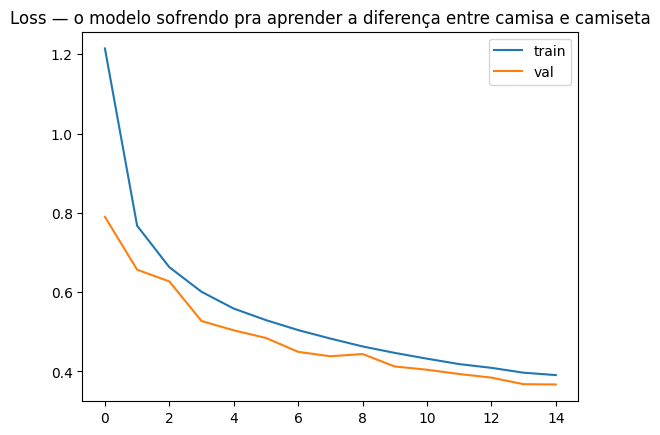

In [19]:
#loss
plt.plot(r.history['loss'], label='train')
plt.plot(r.history['val_loss'], label='val')
plt.title('Loss — o modelo sofrendo pra aprender a diferença entre camisa e camiseta')
plt.legend()
plt.show()

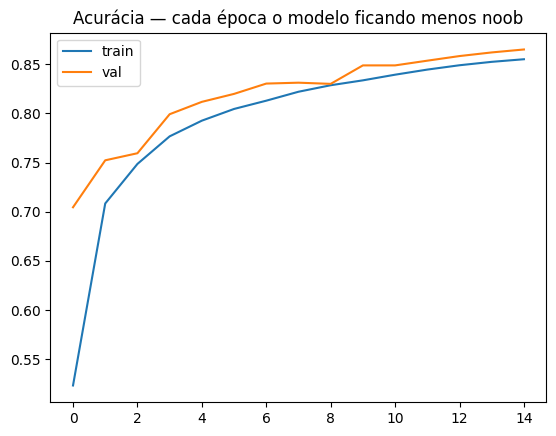

In [20]:
# acurácia
plt.plot(r.history['accuracy'], label='train')
plt.plot(r.history['val_accuracy'], label='val')
plt.title('Acurácia — cada época o modelo ficando menos noob')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


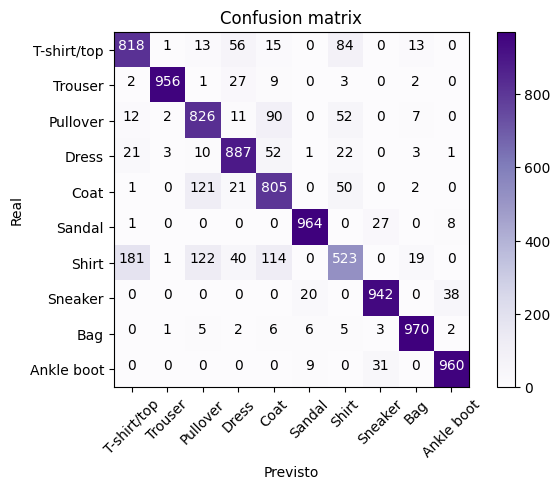

In [21]:
from sklearn.metrics import confusion_matrix
import itertools
def plot_confusion_matrix(cm, classes, normalize=False,
                          title='Confusion matrix', cmap=plt.cm.Purples):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')
    plt.tight_layout()
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    plt.show()

labels = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
          'Sandal','Shirt','Sneaker','Bag','Ankle boot']

p_test = model.predict(x_test).argmax(axis=1)
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, labels)


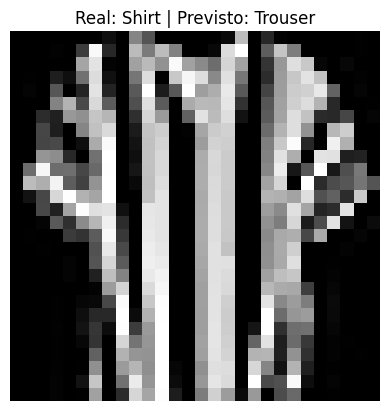

In [22]:
# Um erro aleatório da criação do modelo
misclassified_idx = np.where(p_test != y_test)[0]
idx = np.random.choice(misclassified_idx)
plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')
plt.title(f'Real: {labels[y_test[idx]]} | Previsto: {labels[p_test[idx]]}')
plt.axis('off')
plt.show()

## Inproving_CIFAR_Prática

In [23]:
# bibliotecas
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [24]:
# treinamento e importação
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = y_train.flatten(), y_test.flatten()
print(x_train.shape)

(50000, 32, 32, 3)


In [25]:
#classes
K = len(set(y_train))
print('classes:', K)

classes: 10


In [26]:
i = Input(shape=x_train[0].shape)

# kernel maior pra pegar features amplas
x = Conv2D(32, (5, 5), activation='relu', padding='same')(i)
x = BatchNormalization()(x)
x = MaxPooling2D(2, 2)(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(2, 2)(x)
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)

# globalAveragePooling  mais leve que Flatten
x = GlobalAveragePooling2D()(x)

x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,274 (512.79 KB)

 Trainable params: 130,826 (511.04 KB)

 Non-trainable params: 448 (1.75 KB)

In [27]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
train_gen = datagen.flow(x_train, y_train, batch_size=32)
steps = x_train.shape[0] // 32

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

r = model.fit(train_gen, steps_per_epoch=steps, epochs=15,
              validation_data=(x_test, y_test))

Epoch 1/15
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 114s 72ms/step - accuracy: 0.4397 - loss: 1.5313 - val_accuracy: 0.4981 - val_loss: 1.3802
Epoch 2/15
   1/1562 ━━━━━━━━━━━━━━━━━━━━ 3:23 130ms/step - accuracy: 0.5312 - loss: 1.4402

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1562/1562 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5312 - loss: 1.4402 - val_accuracy: 0.4804 - val_loss: 1.4613
Epoch 3/15
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 137s 73ms/step - accuracy: 0.5555 - loss: 1.2420 - val_accuracy: 0.5448 - val_loss: 1.2761
Epoch 4/15
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7500 - loss: 0.9087 - val_accuracy: 0.5339 - val_loss: 1.2880
Epoch 5/15
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 110s 71ms/step - accuracy: 0.5996 - loss: 1.1240 - val_accuracy: 0.5573 - val_loss: 1.2481
Epoch 6/15
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7812 - loss: 0.8690 - val_accuracy: 0.5610 - val_loss: 1.2464
Epoch 7/15
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 138s 72ms/step - accuracy: 0.6314 - loss: 1.0491 - val_accuracy: 0.6039 - val_loss: 1.1139
Epoch 8/15
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6250 - loss: 1.0133 - val_accuracy: 0.6045 - val_loss: 1.1133
Epoch 9/15
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 136s 72ms/step - accuracy: 0.6512 - loss: 0.9972 -

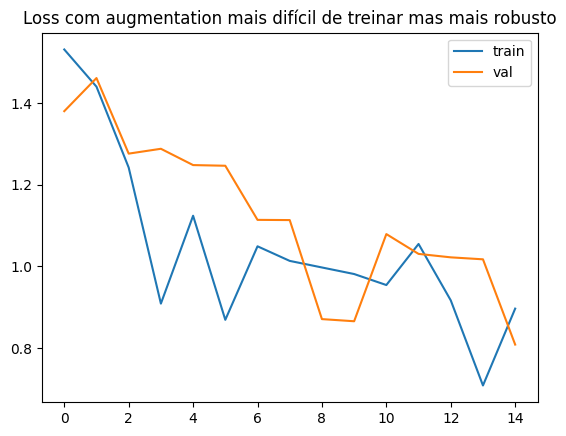

In [28]:
#Loss
plt.plot(r.history['loss'], label='train')
plt.plot(r.history['val_loss'], label='val')
plt.title('Loss com augmentation mais difícil de treinar mas mais robusto')
plt.legend()
plt.show()

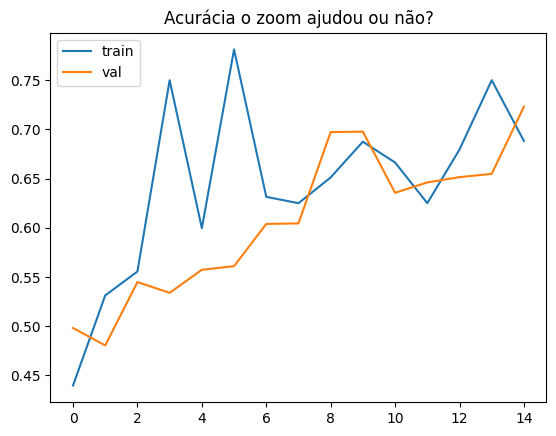

In [29]:
# acurácia
plt.plot(r.history['accuracy'], label='train')
plt.plot(r.history['val_accuracy'], label='val')
plt.title('Acurácia o zoom ajudou ou não?')
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


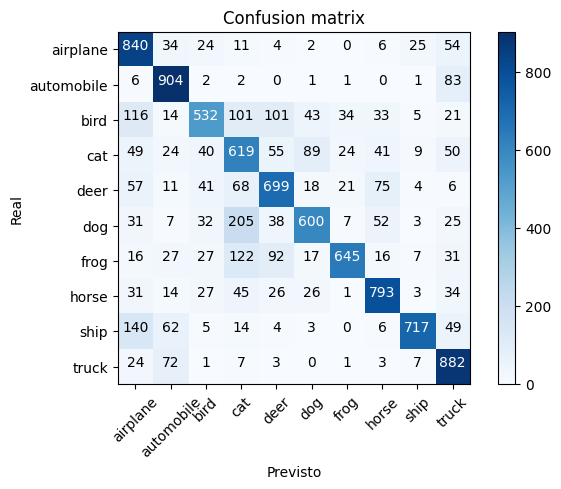

In [30]:
from sklearn.metrics import confusion_matrix
import itertools
def plot_confusion_matrix(cm, classes, normalize=False,
                          title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')
    plt.tight_layout()
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    plt.show()

labels = ['airplane','automobile','bird','cat','deer',
          'dog','frog','horse','ship','truck']

p_test = model.predict(x_test).argmax(axis=1)
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, labels)

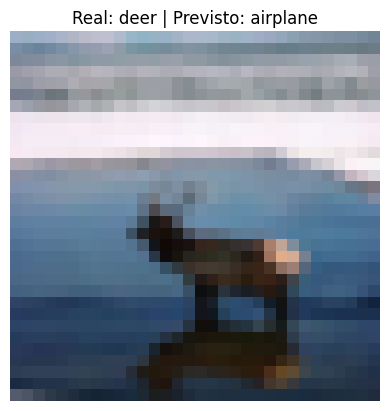

In [31]:
# erro do modelo
misclassified_idx = np.where(p_test != y_test)[0]
idx = np.random.choice(misclassified_idx)
plt.imshow(x_test[idx])
plt.title(f'Real: {labels[y_test[idx]]} | Previsto: {labels[p_test[idx]]}')
plt.axis('off')
plt.show()